<a href="https://colab.research.google.com/github/Qunzh/CAN_GridCell_Model/blob/main/Ring_Model_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [181]:
def ring_model_(epsilon, theta_cue, A, c, n_number, tau, J_0, J_2, dt, total_t, theta_0_param, a_param):

  # Initialization - EXACTLY matching original
  t_steps = int(total_t/dt)
  rate = np.zeros((t_steps, n_number))
  I_theta = np.zeros((t_steps, n_number))  # Store for verification
  recurrent = np.zeros((t_steps, n_number))  # Store for verification
  h_theta = np.zeros((n_number))

  # Neuron Label
  theta_i = np.zeros((n_number))
  for i in range(0, n_number):
    theta_i[i] = (np.pi/n_number) * i - np.pi/2

  # Intial Conditions
  a = 2
  theta_0 = 0
  for i in range(0, n_number):
    rate[0, i] = a * np.cos(2 * (theta_i[i] - theta_0))

  # Thalamic input
  for i in range(0, n_number):
    h_theta[i] = A * c * (1 - epsilon + epsilon * np.cos(2 * (theta_i[i] - theta_cue)))

  # Pre-compute connectivity matrix
  theta_diff = theta_i[:, np.newaxis] - theta_i[np.newaxis, :]
  W = (J_0 + J_2 * np.cos(2 * theta_diff)) * (np.pi / n_number)

  # Time integration
  for t in range(0, t_steps):
    # Vectorized recurrent calculation
    recurrent[t, :] = W @ rate[t-1, :]

    # Total input
    I_theta[t, :] = h_theta + recurrent[t, :]

    # Rectification
    I_theta[t, :] = np.maximum(I_theta[t, :], 0)

    # Euler integration
    drdt = (-rate[t-1, :] + I_theta[t, :]) / tau
    rate[t, :] = rate[t-1, :] + drdt * dt

  steady_state = rate[t, :]
  return theta_i, steady_state

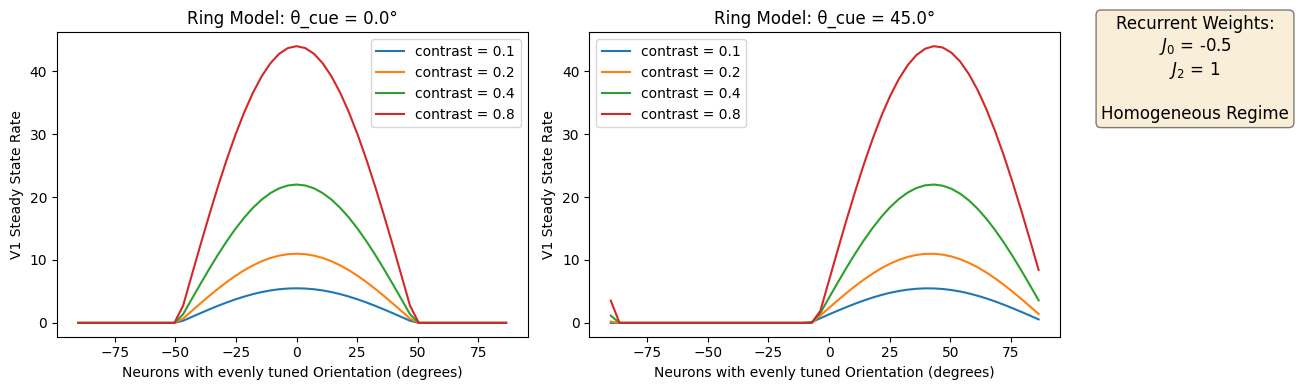

In [183]:
# Homogeneous regime (with small recurrent exictation J_2 and small recurrent inhibition J_0)
J_0, J_2 = -0.5, 1
contrast_values = [0.1, 0.2, 0.4, 0.8]
theta_cue_values = [0, np.pi/4]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, theta_cue in enumerate(theta_cue_values):
    ax = axes[idx]
    for c in contrast_values:
        theta_i, steady_state = ring_model(0.1, theta_cue, 40, c, 50, 10, J_0, J_2, 0.05, 300, np.pi/4, 2)
        ax.plot(np.rad2deg(theta_i), steady_state, label=f'contrast = {c}')

    ax.set_xlabel('Neurons with evenly tuned Orientation (degrees)')
    ax.set_ylabel('V1 Steady State Rate')
    ax.set_title(f'Ring Model: θ_cue = {np.rad2deg(theta_cue):.1f}°')
    ax.legend()

textstr = f'Recurrent Weights:\n$J_0$ = {J_0}\n$J_2$ = {J_2}\n\nHomogeneous Regime'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
fig.text(1, 0.95, textstr, transform=fig.transFigure, fontsize=12,
         verticalalignment='top', horizontalalignment='center', bbox=props)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()